**DATA COLLECTION**

In [ ]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Uploading CSV file
from google.colab import files
uploaded = files.upload()

# Reading the CSV file using pandas
df = pd.read_csv('Sample - Superstore.csv', encoding = 'latin1')

# Get total number of columns and rows
print("Total number of rows and columns = ", df.shape)

# Get an overview of the top 10 rows
df.head(10)

Saving Sample - Superstore.csv to Sample - Superstore.csv
Total number of rows and columns =  (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
5,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
6,7,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.2800,4,0.00,1.9656
7,8,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,TEC-PH-10002275,Technology,Phones,Mitel 5320 IP Phone VoIP phone,907.1520,6,0.20,90.7152
8,9,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-BI-10003910,Office Supplies,Binders,DXL Angle-View Binders with Locking Rings by S...,18.5040,3,0.20,5.7825
9,10,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AP-10002892,Office Supplies,Appliances,Belkin F5C206VTEL 6 Outlet Surge,114.9000,5,0.00,34.4700


**DATA CLEANING**

Checking for missing value

In [ ]:
MissingValue_Check = df.isnull().sum()
print(MissingValue_Check)

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


Checking for duplicate values

In [ ]:
DuplicateValues_Check = df.duplicated().sum()
print("Number of duplicate values = ", DuplicateValues_Check)
# There are no duplicate values, hence we do not have to remove any row

Number of duplicate values =  0


Converting data type for the relevant columns

In [ ]:
# Checking data type of the Postal Code column
print(df['Postal Code'].info)

# Since it is currently an integer, its data type must be converted to the String type
df['Postal Code'] = df['Postal Code'].astype(str)

<bound method Series.info of 0       42420
1       42420
2       90036
3       33311
4       33311
        ...  
9989    33180
9990    92627
9991    92627
9992    92627
9993    92683
Name: Postal Code, Length: 9994, dtype: int64>


Cleaning up some columns names

In [ ]:
# The spaces between the column names should be replaced with an underscore
df.columns = df.columns.str.replace(' ', '_')

# Checking the latest columns' names and their data type
print(df.columns)
print()
print(df.dtypes)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code       object
Region            object
Product_ID        object
Category          object
Sub-Category      object
Product_Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


Converting two date columns into datetime objects

In [ ]:
# Date columns' data type is changed from object to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'])

print("New Order Date data structure")
print(df['Order_Date'])
print()
print("New Ship Date data structure")
print(df['Ship_Date'])
print()
print(df.dtypes)

New Order Date data structure
0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order_Date, Length: 9994, dtype: datetime64[ns]

New Ship Date data structure
0      2016-11-11
1      2016-11-11
2      2016-06-16
3      2015-10-18
4      2015-10-18
          ...    
9989   2014-01-23
9990   2017-03-03
9991   2017-03-03
9992   2017-03-03
9993   2017-05-09
Name: Ship_Date, Length: 9994, dtype: datetime64[ns]

Row_ID                    int64
Order_ID                 object
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Ship_Mode                object
Customer_ID              object
Customer_Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal_Code              object
Region                   object
Product_ID          

Identifying outliers in the numerical columns   
*(Outliers are not erased from the data. This is legitimate for business-related data, as these numbers represent high-value transactions and orders)*

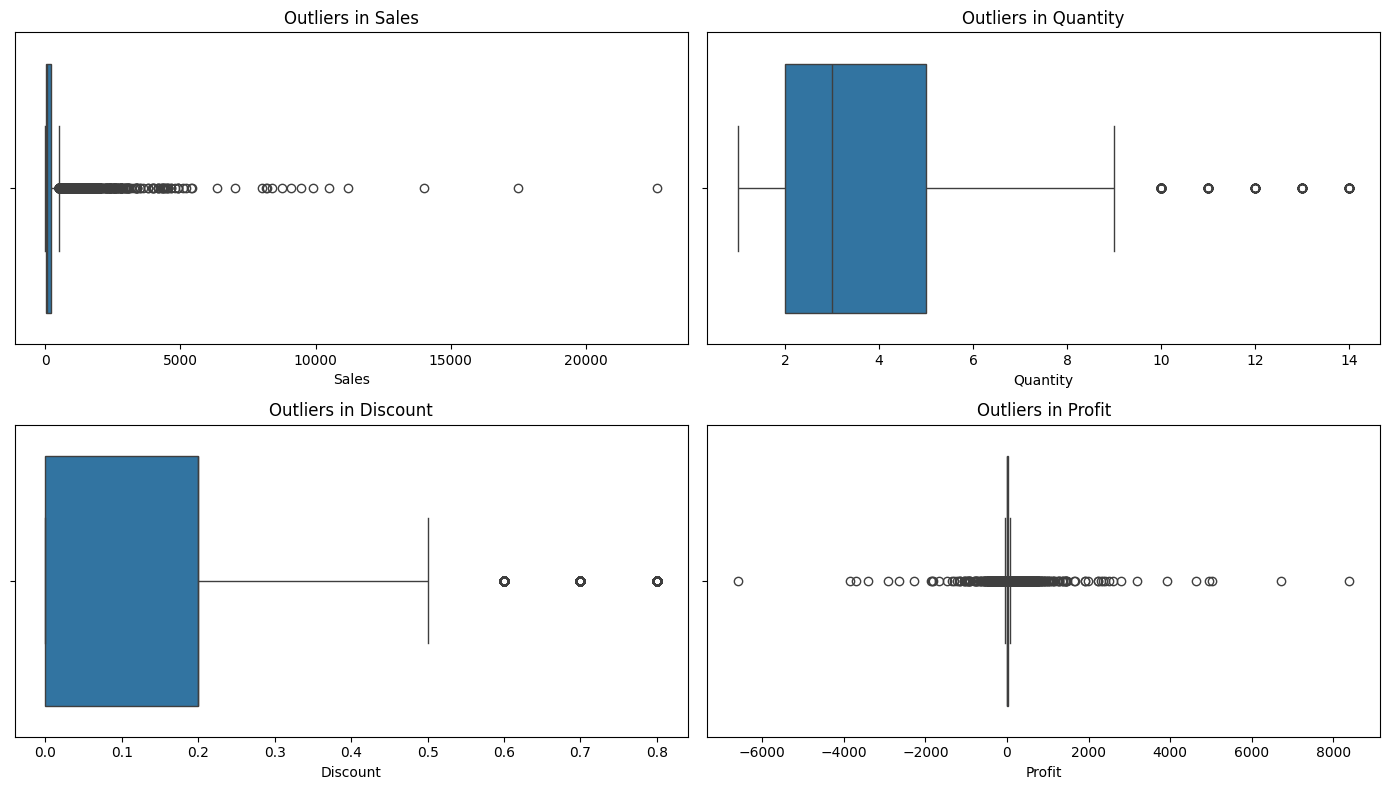

Sales: Found 1167 outliers (Values outside -271.71 to 498.93)
Quantity: Found 170 outliers (Values outside -2.50 to 9.50)
Discount: Found 856 outliers (Values outside -0.30 to 0.50)
Profit: Found 1881 outliers (Values outside -39.72 to 70.82)
These outliers are legitimate and relevant for the analysis


In [ ]:
# Selecting numerical columns
numerical_col = ['Sales', 'Quantity', 'Discount', 'Profit']

# Creating a figure with the respective size
plt.figure(figsize=(14, 8))

# Building a boxplot for each column
for i, col in enumerate(numerical_col, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

# A function to calculate and determine the number of outliers
def count_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Loop through the numerical columns and produce the output
for col in numerical_col:
    count, lb, ub = count_outliers(df, col)
    print(f"{col}: Found {count} outliers (Values outside {lb:.2f} to {ub:.2f})")

print("These outliers are legitimate and relevant for the analysis")

**EXPLORATORY DATA ANALYSIS (EDA)**

Monthly Sales Cashflow (2014-2018)

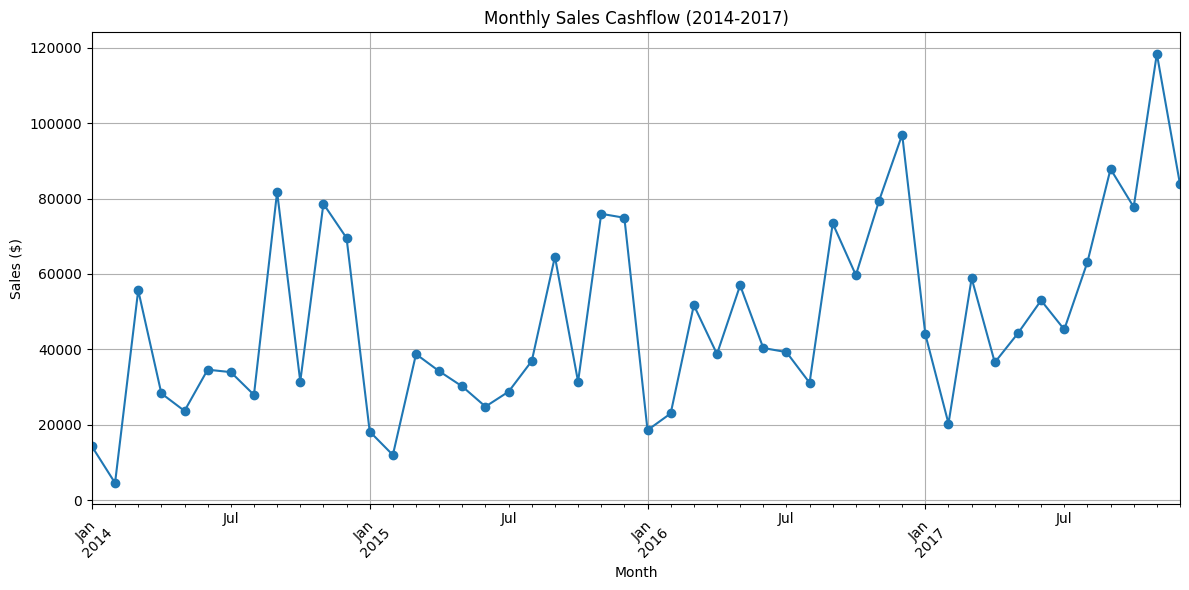

In [ ]:
#Sales cashflow over time (2014-2018)
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)]

df_filtered['YearMonth'] = df_filtered['Order_Date'].dt.to_period('M')

# Group by YearMonth and sum Sales
monthly_sales = df_filtered.groupby('YearMonth')['Sales'].sum()

# Plot the line chart
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Cashflow (2014-2017)')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


*Key Findings*

There is an increment in sales on average from September to December each year.



Monthly Profit (2014-2018)

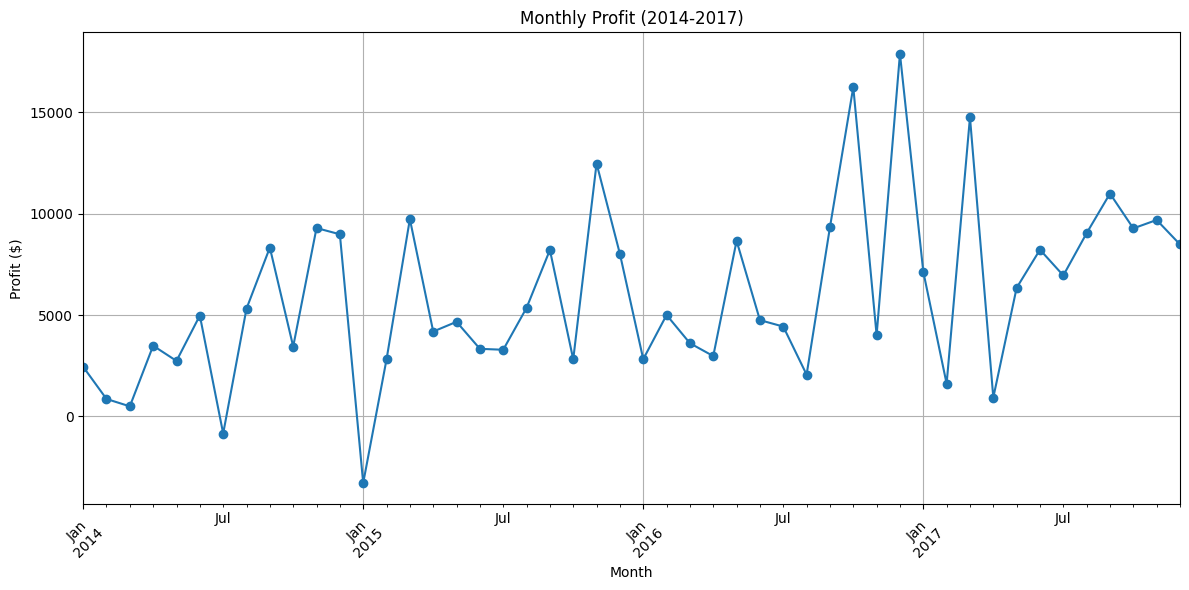

In [ ]:
#Profit cashflow over time
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)]

# Create Year-Month period for grouping
df_filtered['YearMonth'] = df_filtered['Order_Date'].dt.to_period('M')

# Group by YearMonth and sum Sales
monthly_sales = df_filtered.groupby('YearMonth')['Profit'].sum()

# Plot the line chart
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Profit (2014-2017)')
plt.xlabel('Month')
plt.ylabel('Profit ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Key Findings*

Monthly profit seems to increase as we approach the end of each year. The last quarter of each year will, on average, show the highest profitability.

Weekly Sales Cashflow

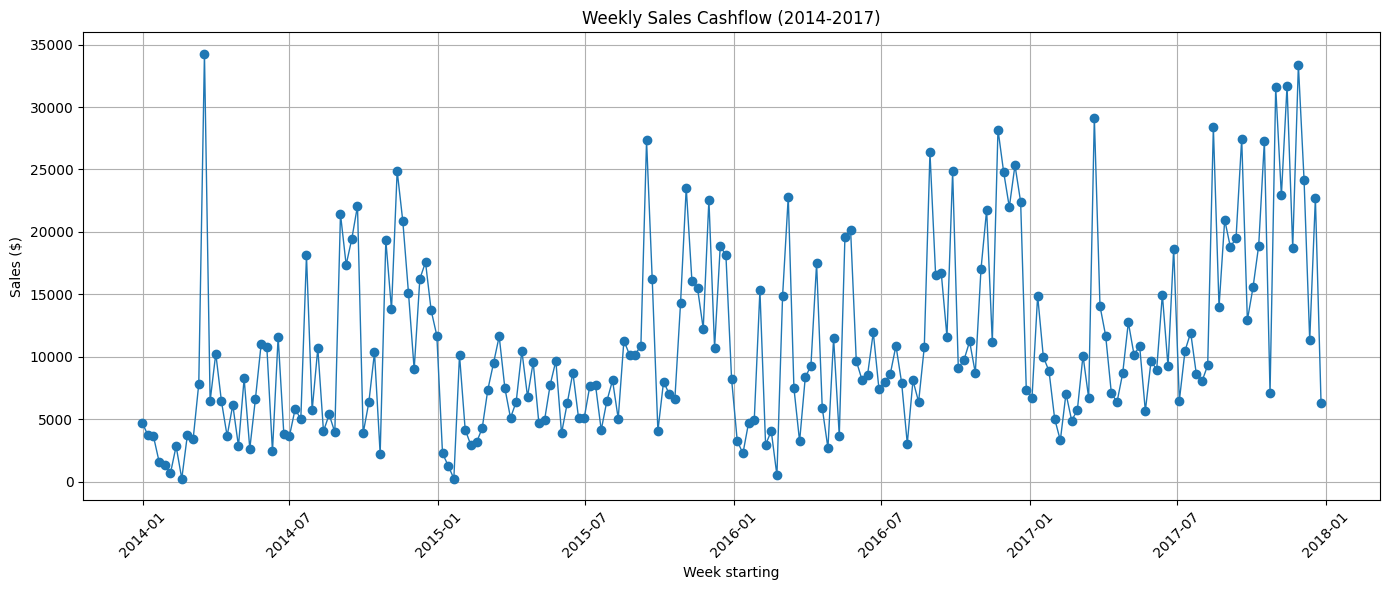

In [ ]:
# Sales cashflow over time (2014-2018) by week
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)].copy()

# Group by week and sum Sales using Monday week boundary
df_filtered['Week_Start'] = df_filtered['Order_Date'].dt.to_period('W-MON').apply(lambda r: r.start_time)
weekly_sales = df_filtered.groupby('Week_Start')['Sales'].sum()

# Plot the weekly line chart
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales.index, weekly_sales.values, marker='o', linewidth=1)
plt.title('Weekly Sales Cashflow (2014-2017)')
plt.xlabel('Week starting')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Key Findings*

There is an increment in sales on average, weekly from September to December each year.

Weekly Profit (2014-2018)

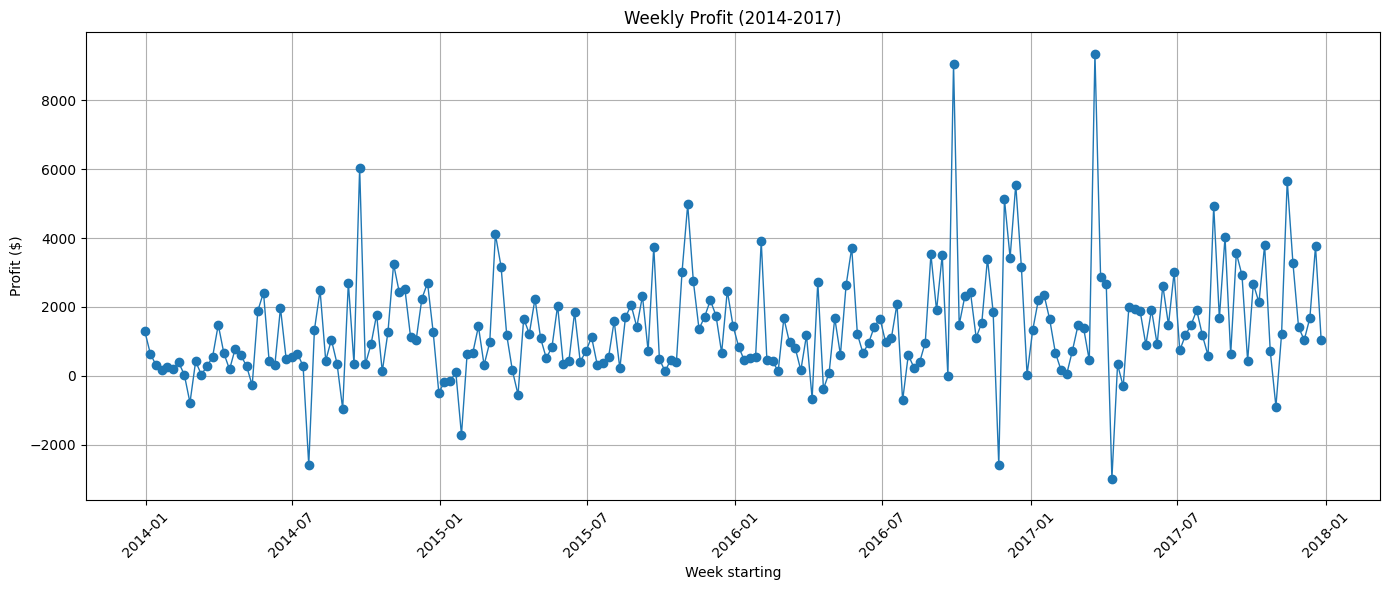

In [ ]:
# Sales cashflow over time (2014-2018) by week
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)].copy()

# Group by week and sum Sales using Monday week boundary
df_filtered['Week_Start'] = df_filtered['Order_Date'].dt.to_period('W-MON').apply(lambda r: r.start_time)
weekly_sales = df_filtered.groupby('Week_Start')['Profit'].sum()

# Plot the weekly line chart
plt.figure(figsize=(14, 6))
plt.plot(weekly_sales.index, weekly_sales.values, marker='o', linewidth=1)
plt.title('Weekly Profit (2014-2017)')
plt.xlabel('Week starting')
plt.ylabel('Profit ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

*Key Findings*

Weekly profit seems to increase as we approach the end of each year. The last quarter of each year will, on average, show the highest profitability.

Total Profit by Sub-Category

Total Profit by Sub-Category:


,Profit
Sub-Category,
Copiers,55617.8249
Phones,44515.7306
Accessories,41936.6357
Paper,34053.5693
Binders,30221.7633
Chairs,26590.1663
Storage,21278.8264
Appliances,18138.0054
Furnishings,13059.1436


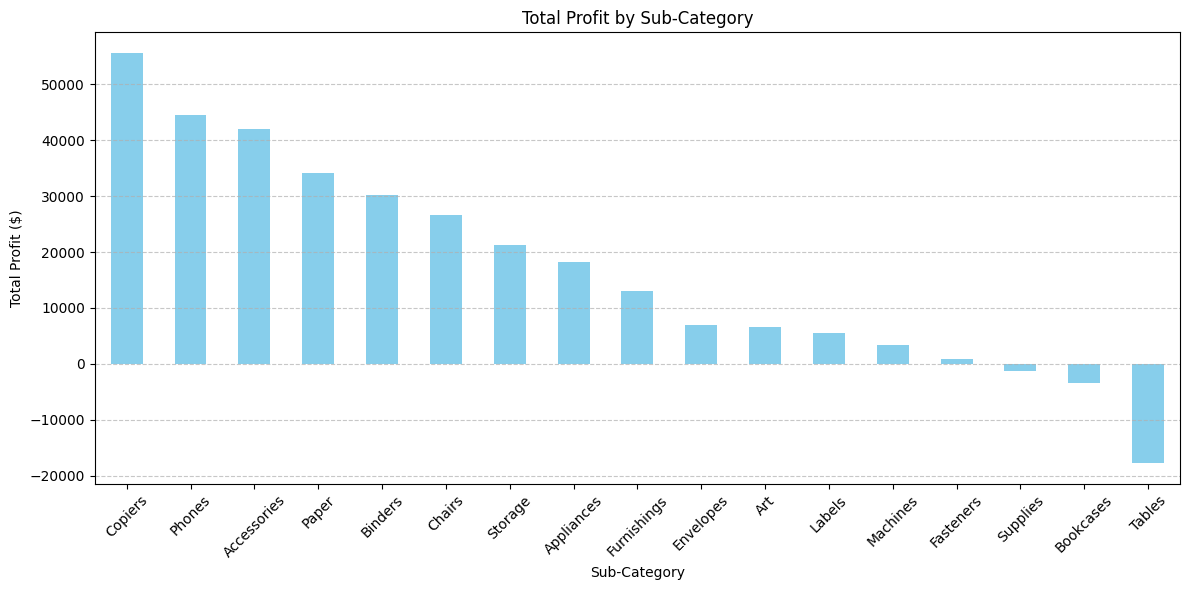

In [ ]:
# Profit by Sub-Category visualization
profit_by_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)

# Display the table
print("Total Profit by Sub-Category:")
display(profit_by_sub.to_frame())

# Bar chart visualization
plt.figure(figsize=(12, 6))
profit_by_sub.plot(kind='bar', color='skyblue')
plt.title('Total Profit by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Profit ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

*Key Findings*

Copiers, Phones, and Accessories are the top-3 highest sub-categories that set the highest profitability.

On the other hand, Tables sub-category shows a negative profit (loss), followed by Bookcases and Supplies.

Geographical Analysis - Which Regions are the powerhouses

/tmp/ipykernel_5240/781575542.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Region_analysis, x='Region', y='Sales', palette='viridis')
/tmp/ipykernel_5240/781575542.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=Region_analysis, x='Region', y='Profit', palette='viridis')


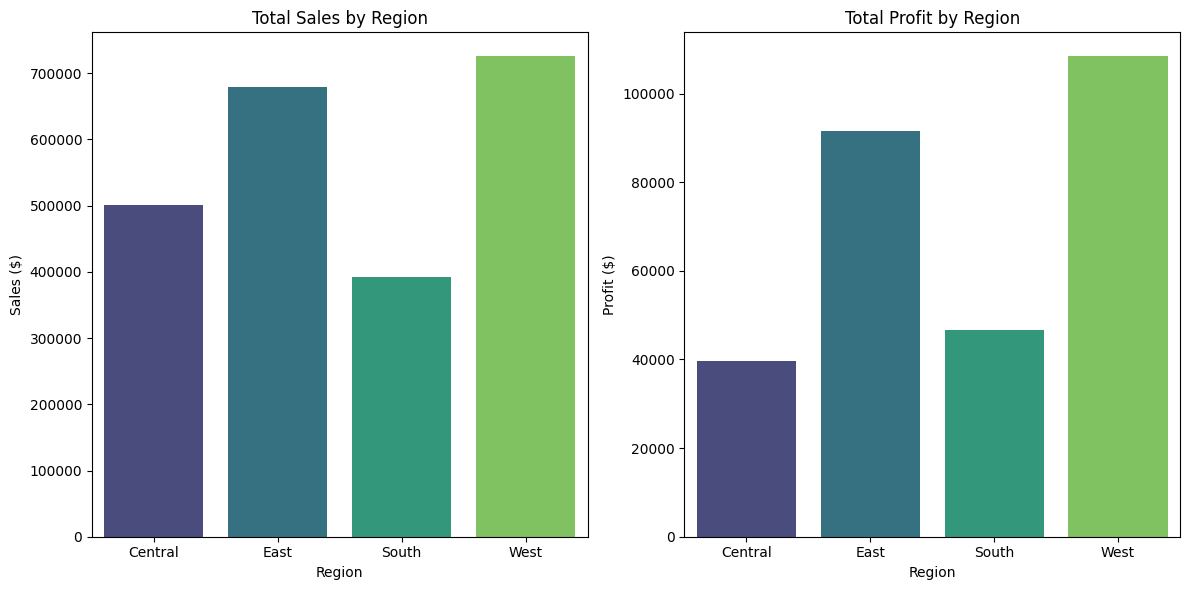

In [ ]:
#Profit cashflow over time (2014-2018)
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)]

# Group by Region and sum Sales and Profit
Region_analysis = df_filtered.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

# Plot the bar charts
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(data=Region_analysis, x='Region', y='Sales', palette='viridis')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales ($)')

plt.subplot(1, 2, 2)
sns.barplot(data=Region_analysis, x='Region', y='Profit', palette='viridis')
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Profit ($)')


plt.tight_layout()
plt.show()

*Key Findings*

The West region sets the highest sales and profitability, followed by The East region.


Althought the Central region sets a greater total sales than the South region, the total profit of the Central region is the lowest among all regions.

The top 5 highest-grossing states and the lowest-grossing states (Profitability)

/tmp/ipykernel_5240/1356161776.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_5.index, y=top_5.values, palette='viridis')
/tmp/ipykernel_5240/1356161776.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bottom_5.index, y=bottom_5.values, palette='plasma')


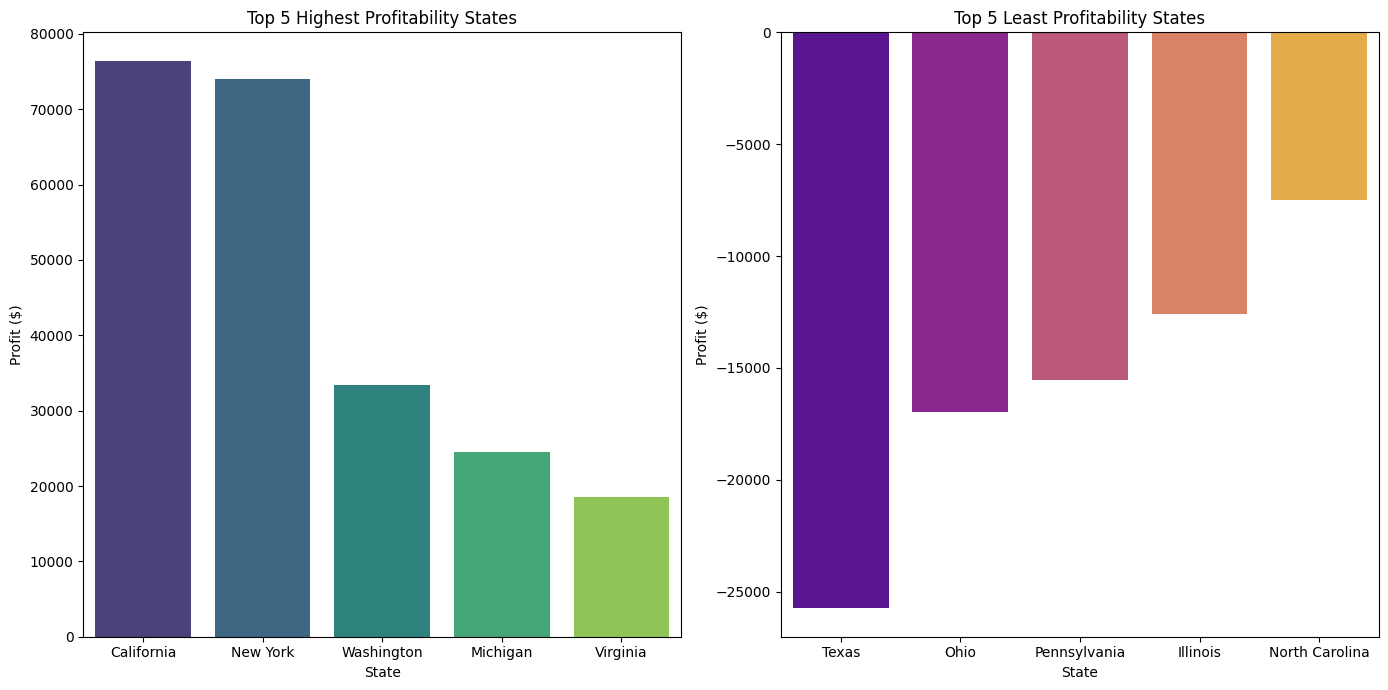

In [ ]:
#Profit cashflow over time (2014-2018)
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)]

# Group by State and sum Profit
State_profit = df_filtered.groupby('State')['Profit'].sum()

# Get the top 5 highest profitability states
top_5 = State_profit.nlargest(5)

# Get the bottom 5 least profitability states
bottom_5 = State_profit.nsmallest(5)

# Plot the bar charts
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
sns.barplot(x=top_5.index, y=top_5.values, palette='viridis')
plt.title('Top 5 Highest Profitability States')
plt.xlabel('State')
plt.ylabel('Profit ($)')

plt.subplot(1, 2, 2)
sns.barplot(x=bottom_5.index, y=bottom_5.values, palette='plasma')
plt.title('Top 5 Least Profitability States')
plt.xlabel('State')
plt.ylabel('Profit ($)')

plt.tight_layout()
plt.show()


*Key Findings*

California is the highest profitability state, followed closely by New York. Both states are classified in the West and East regions. Both states drive the profitability of these two regions.

Meanwhile, the Central region sets the lowest profitability.

Discount correlation with Profitability

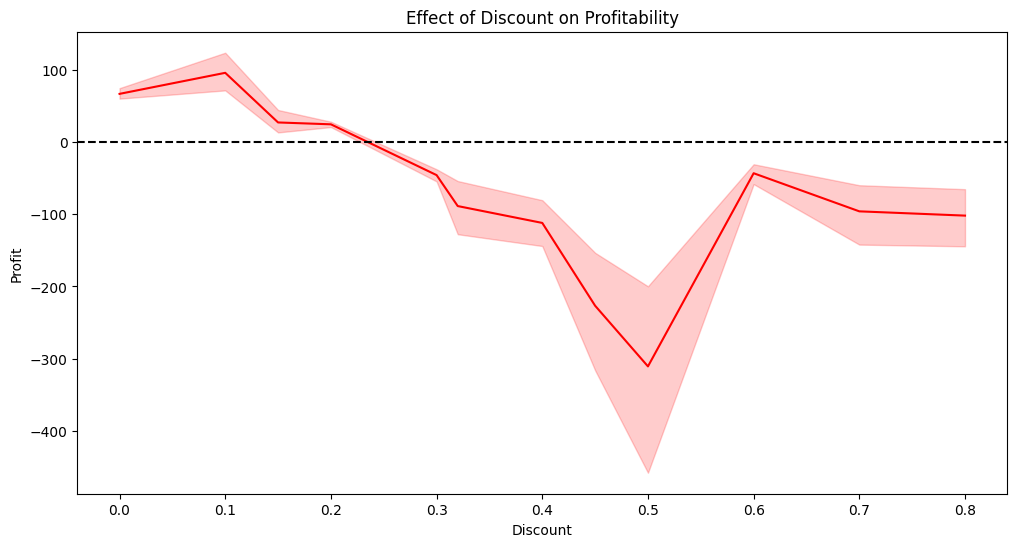

In [ ]:
#Profit cashflow over time (2014-2018)
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)]

#Plot the line graph
plt.figure(figsize=(12, 6))
sns.lineplot(x='Discount', y='Profit', data=df, color='r')
plt.title('Effect of Discount on Profitability')
plt.axhline(0, color='black', linestyle='--')
plt.show()

*Key Findings*

Discounts that are given over 20% causes loses of profitability. Big discounts do not lead to a higher total profit. Apparently, the profit is maximum when the discount given is around 10%.

Total Sales and Profit by Customer Segments

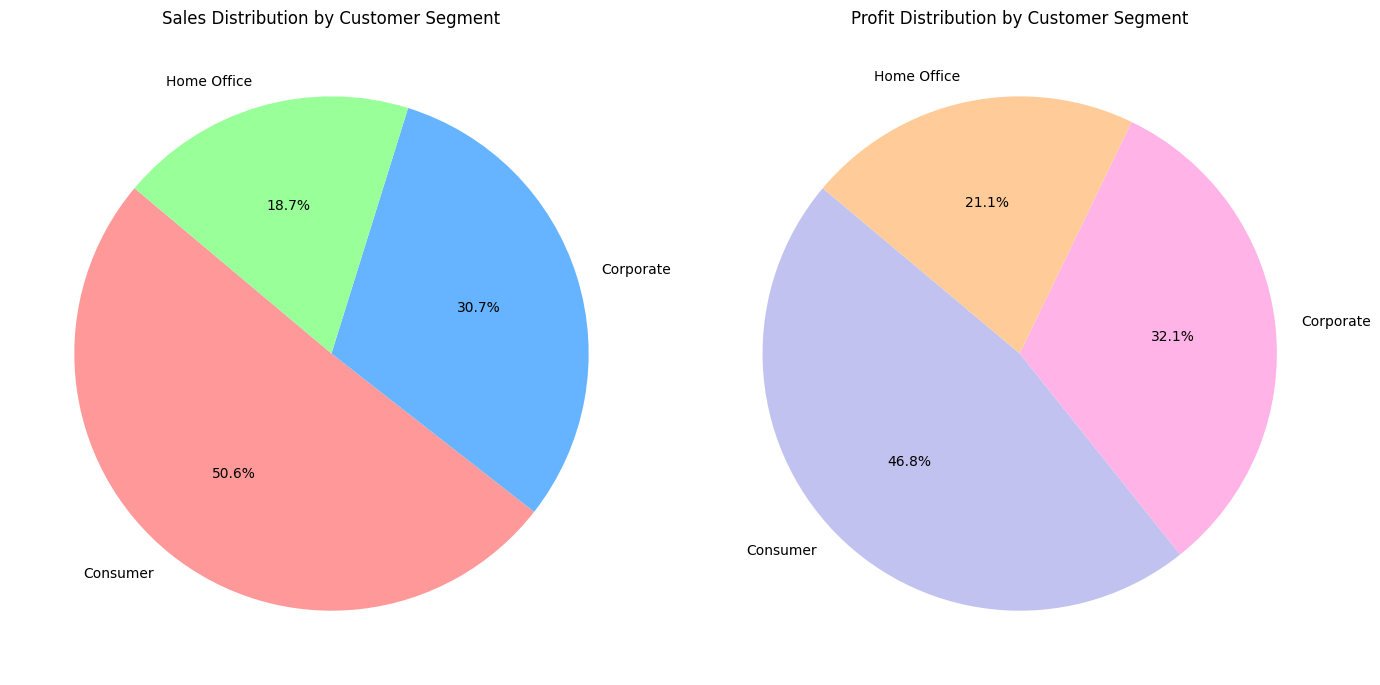

In [ ]:
#Profit cashflow over time (2014-2018)
df_filtered = df[(df['Order_Date'].dt.year >= 2014) & (df['Order_Date'].dt.year <= 2018)]

# Group by Customer Segment and sum Sales and Profit
segment_analysis = df_filtered.groupby('Segment')[['Sales', 'Profit']].sum()

# Creating the pie charts
plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.pie(segment_analysis['Sales'], labels=segment_analysis.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Sales Distribution by Customer Segment')

plt.subplot(1, 2, 2)
plt.pie(segment_analysis['Profit'], labels=segment_analysis.index, autopct='%1.1f%%', startangle=140, colors=['#c2c2f0','#ffb3e6','#ffcc99'])
plt.title('Profit Distribution by Customer Segment')

plt.tight_layout()
plt.show()


*Key Findings*

Consumer has contributed to the highest sales, with over 50% overall. Almost 50% of profitability is contributed by the Consumer group, followed by Corporate and Home Office.

**Correlation Analysis**

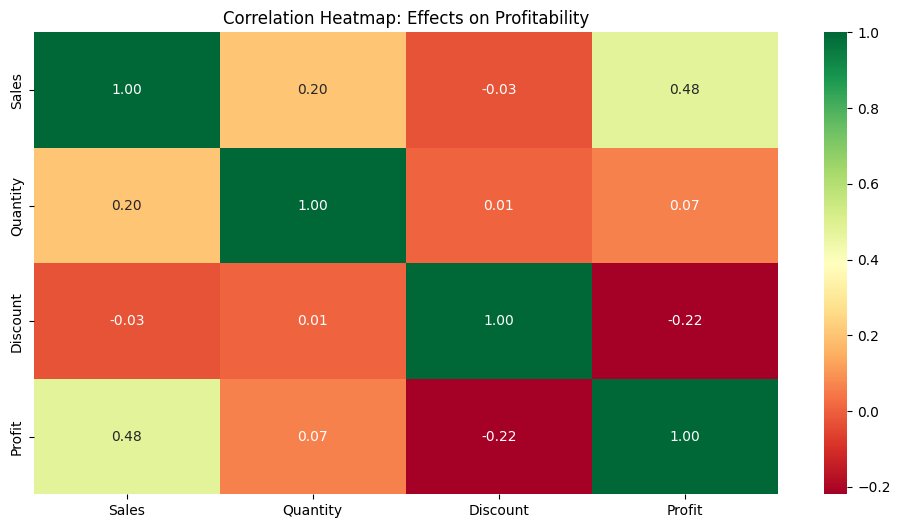

In [ ]:
plt.figure(figsize=(12, 6))
# Calculate correlation on numerical columns
correlation_matrix = df[['Sales', 'Quantity', 'Discount', 'Profit']].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Correlation Heatmap: Effects on Profitability')
plt.show()

*Key Findings*

1. Profit vs Sales: 0.48 (Sales produce a significant
impact (positive correlation) on the profitability. However, some high-value sales might be unprofitable due to discounts)

2. Profit vs Quantity: 0.07 (The value is almost 0. It means selling more items do not mean more profit)

3. Profit vs Discount: -0.22 (This is a negative correlation. As discounts increase, the profitability decreases)

**ML Model Training: Forecasting the Profitability and Sales**

Model 1: Linear Regression Model

Why Linear Regression?

= It assumes a linear relationship between input variables, such as the discount and sales, and the output variable, profit.

Linear Regression Model has successfully predicted the total sales and profit
Metrics Table Report


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Metric,Sales Forecast Model,Profit Forecast Model
0,R-Squared,0.2512,0.2065
1,MSE (Mean Squared Error),465460447.08,14290488.86
2,RMSE (Root Mean Squared Error),$ 21574.53,$ 3780.28
3,MAE (Mean Absolute Error),$ 17457.73,$ 2853.57


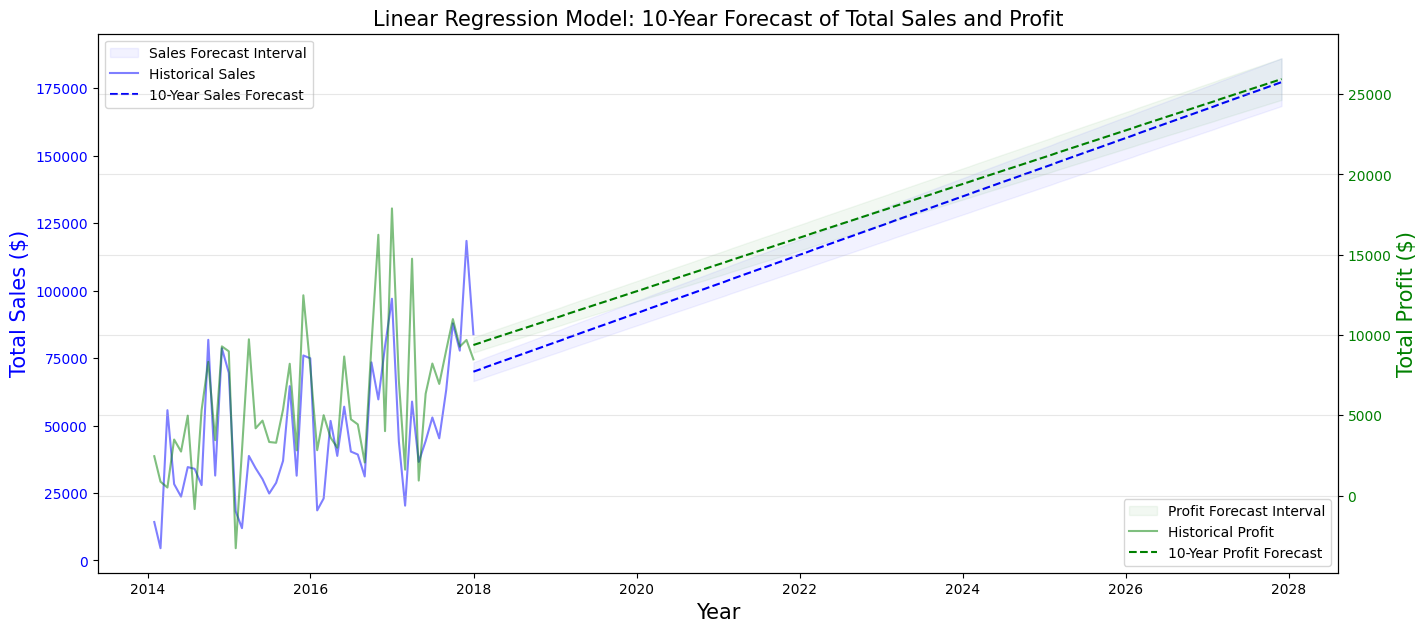

In [ ]:
# Total Sales and Profit by Month Prediction in 10 years (2018 - 2028)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Data Preparation
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
monthly_df = df.resample('ME', on='Order_Date')[['Sales', 'Profit']].sum().reset_index()
monthly_df['Time_Index'] = np.arange(len(monthly_df)).reshape(-1, 1)

# The x and y Axis For Model Training
X = monthly_df[['Time_Index']]
y_sales = monthly_df['Sales']
y_profit = monthly_df['Profit']

# Linear Regression Model Training
model_sales = LinearRegression()
model_sales.fit(X, y_sales)

model_profit = LinearRegression()
model_profit.fit(X, y_profit)

# 10 Years (120 Months) Forecast
last_idx = monthly_df['Time_Index'].max()            #Last Month of the Dataset
future_X = np.arange(last_idx + 1, last_idx + 121).reshape(-1, 1)  #Setting Up the Next 120 Months

# x and y axis For Forecast
forecast_sales = model_sales.predict(future_X)
forecast_profit = model_profit.predict(future_X)
future_dates = pd.date_range(start=monthly_df['Order_Date'].max(), periods=120, freq='ME')

# Metrics' Performance (R-squared, MAE, MSE, RMSE)
sales_preds = model_sales.predict(X)
profit_preds = model_profit.predict(X)

# Calculating Sales Metrics
sales_r2 = r2_score(y_sales, sales_preds)
sales_mae = mean_absolute_error(y_sales, sales_preds)
sales_mse = mean_squared_error(y_sales, sales_preds)
sales_rmse = np.sqrt(sales_mse)

# Calculating Profit Metrics
profit_r2 = r2_score(y_profit, profit_preds)
profit_mae = mean_absolute_error(y_profit, profit_preds)
profit_mse = mean_squared_error(y_profit, profit_preds)
profit_rmse = np.sqrt(profit_mse)

# Creating a Metrics Table
metrics_report = pd.DataFrame({
    'Metric': ['R-Squared', 'MSE (Mean Squared Error)', 'RMSE (Root Mean Squared Error)', 'MAE (Mean Absolute Error)'],
    'Sales Forecast Model': [f"{sales_r2:.4f}", f"{sales_mse:.2f}", f"$ {sales_rmse:.2f}", f"$ {sales_mae:.2f}"],
    'Profit Forecast Model': [f"{profit_r2:.4f}", f"{profit_mse:.2f}", f"$ {profit_rmse:.2f}", f"$ {profit_mae:.2f}"]
})

print("Linear Regression Model has successfully predicted the total sales and profit")
print("Metrics Table Report")
display(metrics_report)

# Prediction Graph Visualization
fig, ax1 = plt.subplots(figsize=(16, 7))

# Adding shades for Sales Forecast
sales_lower = forecast_sales * 0.95  # 5% lower bound
sales_upper = forecast_sales * 1.05  # 5% upper bound
ax1.fill_between(future_dates, sales_lower, sales_upper, color='blue', alpha=0.05, label='Sales Forecast Interval')

ax1.set_xlabel('Year', fontsize = 15)
ax1.set_ylabel('Total Sales ($)', color='blue', fontsize=15)
ax1.plot(monthly_df['Order_Date'], y_sales, label='Historical Sales', color='blue', alpha=0.5)
ax1.plot(future_dates, forecast_sales, label='10-Year Sales Forecast', color='blue', linestyle='--')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()   # The same x-axis is used

# Adding shades for Profit Forecast
profit_lower = forecast_profit * 0.95  # 5% lower bound
profit_upper = forecast_profit * 1.05  # 5% upper bound
ax2.fill_between(future_dates, profit_lower, profit_upper, color='green', alpha=0.05, label='Profit Forecast Interval')

ax2.set_ylabel('Total Profit ($)', color='green', fontsize=15)
ax2.plot(monthly_df['Order_Date'], y_profit, label='Historical Profit', color='green', alpha=0.5)
ax2.plot(future_dates, forecast_profit, label='10-Year Profit Forecast', color='green', linestyle='--')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Linear Regression Model: 10-Year Forecast of Total Sales and Profit', fontsize=15)
ax1.legend(loc='upper left')
ax2.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

*Key Findings*

1. Total sales and profit are predicted to **increase over time consistently**. The overall momentum is positive, although there are a lot of fluctuations in the historical data. The total sales are estimated to reach  **175,000 dollars**, while the total profit is estimated to reach **25,000 dollars by 2028**. The two lines are not converging by 2028, suggesting that the cost is rising almost at the same rate as the sales. The Superstore should look into how to reduce the total cost of sales to ensure that the green profit line can be steeper.

2. The R-squared values for both predictions are **low**. This is because the linear regression model is intended to show the general long-term trend rather than catching small monthly spikes. The model is able to explain around 25% of the sales variation and 21% of the profit variation. The sales model is **more accurate** compared to the profit model, as it is easier to predict total sales than the profitability. This is because profitability is affected by many variables, such as discounts and shipping charges.

3. MAE is added to calculate, on average, how many dollars the prediction is off by. It can be used for risk management by keeping a financial buffer and knowing the average error. RMSE is higher than MAE, indicating that there are **occasional outlier months** with very high or low sales. Additionally, the business organization can keep a cash reserve, which is equal to the RMSE ($3,780), to cover unexpected profit dips in a particular month.